## Stepan-VORONYI-Camp-2026
# Hometask lesson 12:Recomendation Systems

## 1.Replicate Simple recommender implementation
## 2.(optional) Replicate the the content based recommender implementation

# 1.So in this task we need to replicate simple recommender implementation using tutorial left in hometask
## Load Dataset

In [3]:
import pandas as pd
metadata = pd.read_csv('data\movies_metadata.csv', low_memory=False)
metadata.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


## Check Dataset

In [4]:
print('df.shape=', metadata.shape)
print(metadata.columns)

df.shape= (45466, 24)
Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')


## Selecting needed columns, drop null values 

In [5]:
metadata = metadata[['title', 'genres', 'release_date', 'runtime', 'vote_average', 'vote_count', 'overview', 'id']]
metadata = metadata.dropna(subset=['vote_average', 'vote_count'])

print(metadata.shape)
metadata.head()

(45460, 8)


,title,genres,release_date,runtime,vote_average,vote_count,overview,id
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",1995-10-30,81.0,7.7,5415.0,"Led by Woody, Andy's toys live happily in his ...",862
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",1995-12-15,104.0,6.9,2413.0,When siblings Judy and Peter discover an encha...,8844
2,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",1995-12-22,101.0,6.5,92.0,A family wedding reignites the ancient feud be...,15602
3,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",1995-12-22,127.0,6.1,34.0,"Cheated on, mistreated and stepped on, the wom...",31357
4,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",1995-02-10,106.0,5.7,173.0,Just when George Banks has recovered from his ...,11862


## Calculate average rating and vote treshold
C is the mean vote across the whole report

m is the minimum votes required to be listed in the chart

In [6]:
C = metadata['vote_average'].mean()
m = metadata['vote_count'].quantile(0.9)

print(f"C: {C}")
print(f"m: {m}")

C: 5.618207215134184
m: 160.0


## Filter all movies so only qualified ones left

In [7]:
q_movies = metadata.copy().loc[metadata['vote_count'] >= m]

print(f"Amount of movies before filtering: {metadata.shape[0]}")
print(f"Amount of movies after filtering (q_movies): {q_movies.shape[0]}")

Amount of movies before filtering: 45460
Amount of movies after filtering (q_movies): 4555


# Calculate Weighted Rating
$$WR = \left(\frac{v}{v + m} \cdot R\right) + \left(\frac{m}{v + m} \cdot C\right)$$

So we already have m and C we will simply apply IMDB Weighted formula

In [8]:
def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']

    return (v/(v+m) * R) + (m/(m+v) * C)

## Define a new feature and calculate it with weighted rating

In [9]:
q_movies['score'] = q_movies.apply(weighted_rating, axis=1)

## Now we sort movie based on our new feature

In [10]:
q_movies = q_movies.sort_values('score', ascending=False)
q_movies[['title', 'vote_count', 'vote_average', 'score']].head(20)

,title,vote_count,vote_average,score
314,The Shawshank Redemption,8358.0,8.5,8.445869
834,The Godfather,6024.0,8.5,8.425439
10309,Dilwale Dulhania Le Jayenge,661.0,9.1,8.421453
12481,The Dark Knight,12269.0,8.3,8.265477
2843,Fight Club,9678.0,8.3,8.256385
292,Pulp Fiction,8670.0,8.3,8.251406
522,Schindler's List,4436.0,8.3,8.206639
23673,Whiplash,4376.0,8.3,8.205404
5481,Spirited Away,3968.0,8.3,8.196055
2211,Life Is Beautiful,3643.0,8.3,8.187171


## Visualize results for visual pleasure

C:\Users\Stepan\AppData\Local\Temp\ipykernel_24384\3448747446.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='title', data=top_10, palette='viridis')


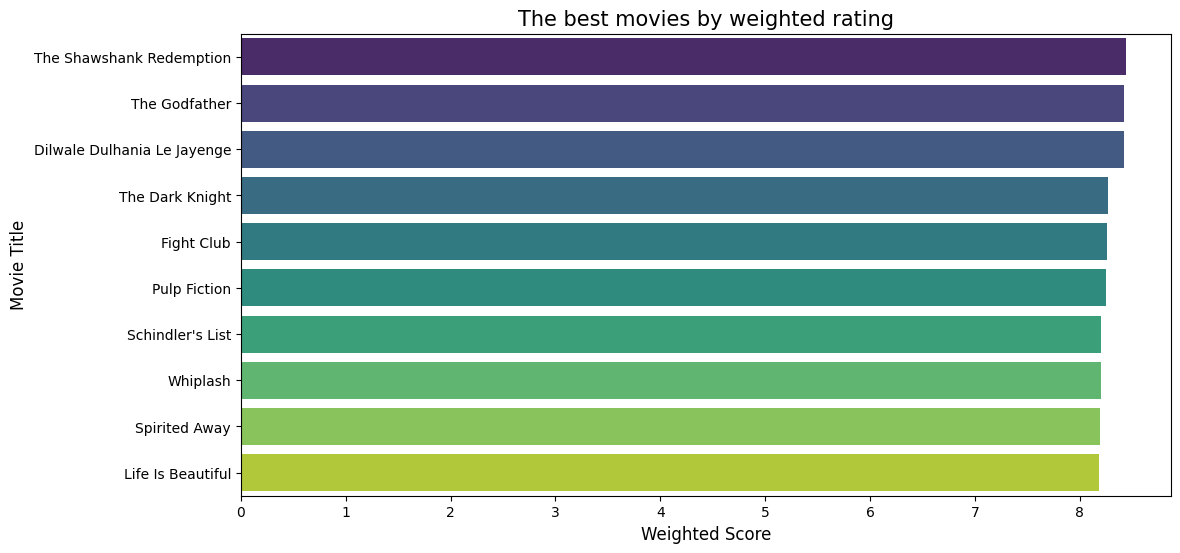

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10 = q_movies.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='score', y='title', data=top_10, palette='viridis')

plt.title('The best movies by weighted rating', fontsize=15)
plt.xlabel('Weighted Score', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.show()

# 2. (Optional) in this task we need to replicate content based recommender implementation

## Data overview

In [12]:
metadata['overview'].head()

0    Led by Woody, Andy's toys live happily in his ...
1    When siblings Judy and Peter discover an encha...
2    A family wedding reignites the ancient feud be...
3    Cheated on, mistreated and stepped on, the wom...
4    Just when George Banks has recovered from his ...
Name: overview, dtype: object

## In this block we prepare data for TF-IDF

We fill nan with empty string cause TF-IDF doesn't work with NaN

We create TF-IDF object and delete stop words as 'the', 'a', 'is'

We create TF-IDF matrix 

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

metadata['overview'] = metadata['overview'].fillna('')
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(metadata['overview'])

print(tfidf_matrix.shape)

(45460, 75827)


## Get feature names for indices 

In [16]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[5000:5010])

['avails' 'avaks' 'avalanche' 'avalanches' 'avallone' 'avalon' 'avant'
 'avanthika' 'avanti' 'avaracious']


## We calculate cosine similarity matrix

So we could calculate the similarity between movies the closer vectores are the more similar those movies are

In [17]:
from sklearn.metrics.pairwise import linear_kernel

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
cosine_sim.shape

(45460, 45460)

## Construct reverse map of indices and movie titles

In [19]:
indices = pd.Series(metadata.index, index=metadata['title']).drop_duplicates()
indices[:10]

title
Toy Story                      0
Jumanji                        1
Grumpier Old Men               2
Waiting to Exhale              3
Father of the Bride Part II    4
Heat                           5
Sabrina                        6
Tom and Huck                   7
Sudden Death                   8
GoldenEye                      9
dtype: int64

## Realisation of Recomendation function

First of we get indice of film that match the title

Then we get the pairwsie similarity scores of all movies with that movie

Sort the movies based on the similarity scores

Get the scores of the 10 most similar movies

Get the movie indices

Return the top 10 most similar movies

In [20]:
def get_recommendations(title, cosine_sim=cosine_sim):

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]

    return metadata['title'].iloc[movie_indices]

## See the result

In [22]:
get_recommendations('The Dark Knight Rises')

12481                                      The Dark Knight
150                                         Batman Forever
1328                                        Batman Returns
15511                           Batman: Under the Red Hood
585                                                 Batman
21194    Batman Unmasked: The Psychology of the Dark Kn...
9230                    Batman Beyond: Return of the Joker
18035                                     Batman: Year One
19792              Batman: The Dark Knight Returns, Part 1
3095                          Batman: Mask of the Phantasm
Name: title, dtype: object

## Then we test on another goated movie

In [ ]:
get_recommendations('The Shawshank Redemption')

1178               The Godfather: Part II
44030    The Godfather Trilogy: 1972-1990
1914              The Godfather: Part III
23126                          Blood Ties
11297                    Household Saints
34717                   Start Liquidation
10821                            Election
38030            A Mother Should Be Loved
17729                   Short Sharp Shock
26293                  Beck 28 - Familjen
Name: title, dtype: object